# Repair Cafe's Worldwide
## 2026-04-07

https://github.com/rfordatascience/tidytuesday/blob/main/data/2026/2026-04-07/readme.md

In [2]:
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 

In [4]:
repairs = pd.read_csv('https://raw.githubusercontent.com/rfordatascience/tidytuesday/main/data/2026/2026-04-07/repairs.csv')
repairs.tail(2)

,repair_id,repair_date,repair_cafe_number,repair_cafe_name,country,kind_of_product,category,brand,estimated_year_of_production,repaired,repairability
178747,0007_2017_0401_167,2017-04-01,7.0,Oirsbeek,NL,Electric kettle / Electric jug,Household appliances electric,Inventum,2010.0,yes,8.0
178748,0016_2017_0404_264,2017-04-04,NaN,NaN,NL,Label printer,NaN,Dymo,NaN,yes,10.0


In [5]:
repairs_text = pd.read_csv('https://raw.githubusercontent.com/rfordatascience/tidytuesday/main/data/2026/2026-04-07/repairs_text.csv')
repairs_text.tail(2)

,repair_id,model,defect_found,problem_description,repair_method,partial_repair_notes,failure_reasons,failure_reason_open,used_repair_info,repair_info_source,repair_info_url,suggestions
178747,0007_2017_0401_167,nvt,"knopje afgebroken, doet het niet",NaN,knopje gemaakt met 3D printer,NaN,NaN,NaN,no,NaN,NaN,NaN
178748,0016_2017_0404_264,Letra tag xm,NaN,Afdrukken zijn onduidelijk sinds het nieuwe lint,nieuwe batterijen,NaN,NaN,NaN,yes,NaN,user,NaN


C:\Users\vivek\AppData\Local\Temp\ipykernel_23008\4238028807.py:59: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .resample('M')


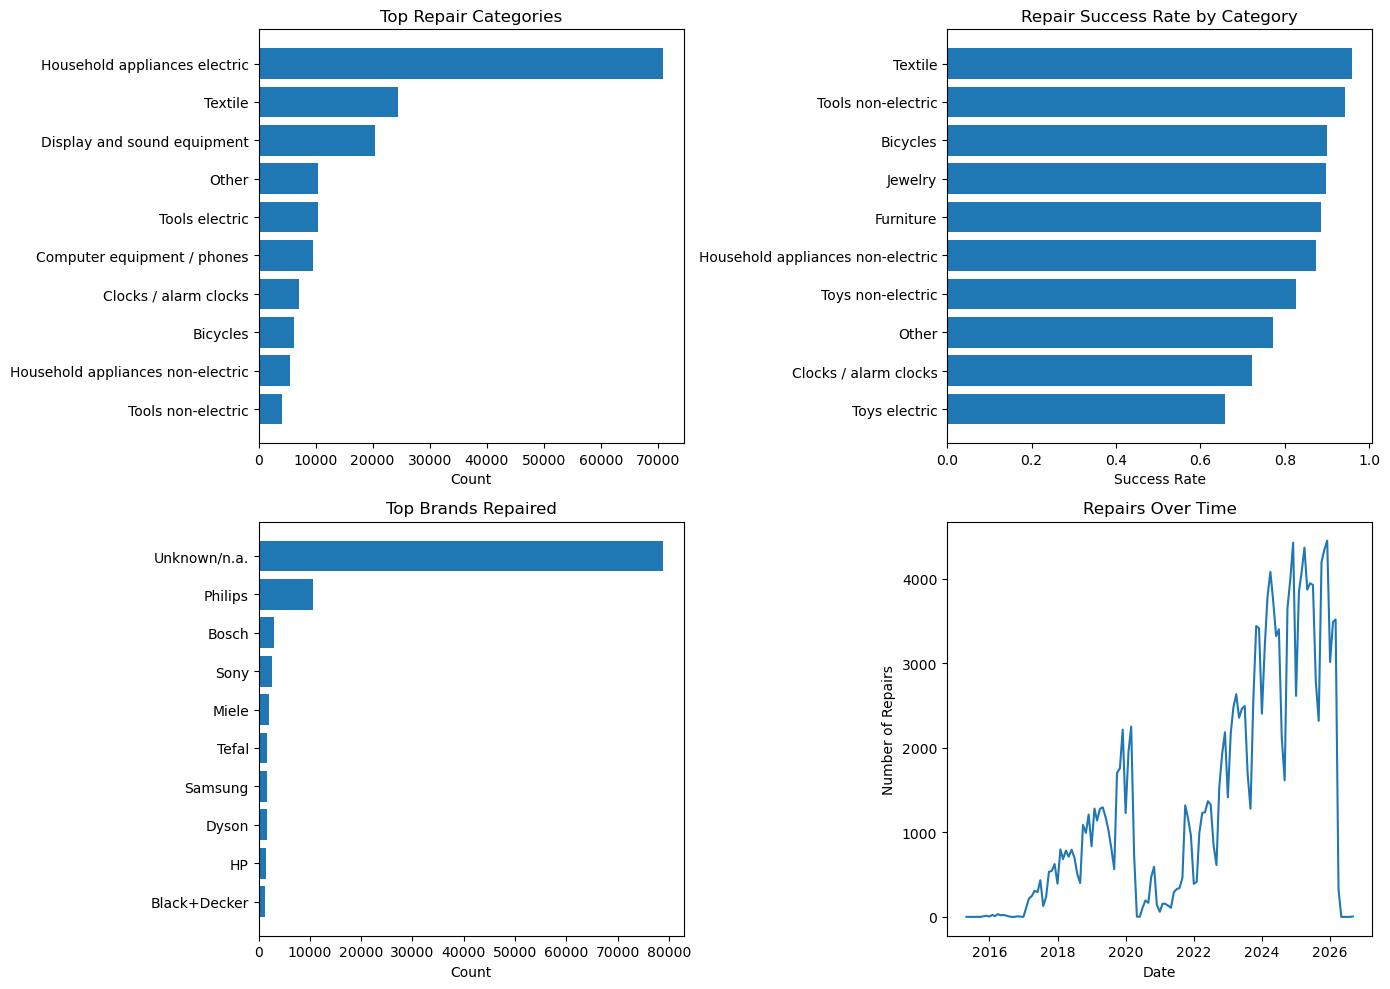

In [6]:
# --- Basic cleaning ---
repairs['repair_date'] = pd.to_datetime(repairs['repair_date'], errors='coerce')

# Normalize repaired column
repairs['repaired'] = repairs['repaired'].str.lower().map({'yes': 1, 'no': 0})

# --- Create figure ---
fig, axs = plt.subplots(2, 2, figsize=(14, 10))

# -------------------------------
# (1) Top Categories
# -------------------------------
top_categories = (
    repairs['category']
    .dropna()
    .value_counts()
    .head(10)
)

axs[0, 0].barh(top_categories.index[::-1], top_categories.values[::-1])
axs[0, 0].set_title("Top Repair Categories")
axs[0, 0].set_xlabel("Count")

# -------------------------------
# (2) Repair Success Rate by Category
# -------------------------------
success_rate = (
    repairs.dropna(subset=['category', 'repaired'])
    .groupby('category')['repaired']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

axs[0, 1].barh(success_rate.index[::-1], success_rate.values[::-1])
axs[0, 1].set_title("Repair Success Rate by Category")
axs[0, 1].set_xlabel("Success Rate")

# -------------------------------
# (3) Top Brands
# -------------------------------
top_brands = (
    repairs['brand']
    .dropna()
    .value_counts()
    .head(10)
)

axs[1, 0].barh(top_brands.index[::-1], top_brands.values[::-1])
axs[1, 0].set_title("Top Brands Repaired")
axs[1, 0].set_xlabel("Count")

# -------------------------------
# (4) Repairs Over Time
# -------------------------------
repairs_over_time = (
    repairs.dropna(subset=['repair_date'])
    .set_index('repair_date')
    .resample('M')
    .size()
)

axs[1, 1].plot(repairs_over_time.index, repairs_over_time.values)
axs[1, 1].set_title("Repairs Over Time")
axs[1, 1].set_xlabel("Date")
axs[1, 1].set_ylabel("Number of Repairs")

# -------------------------------
# Layout Fix
# -------------------------------
plt.tight_layout()

plt.show()